In [1]:
!pip install xgboost
!pip install imbalanced-learn
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [4]:
import pandas as pd
import numpy as np
import category_encoders as ce

# Đọc dữ liệu
customer_data = pd.read_csv("/content/Book1.csv")

# Copy dữ liệu
dataset = customer_data.copy()

# Xử lý missing values
missing_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

for col in missing_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

# Bỏ CustomerID
dataset = dataset.drop(columns=["CustomerID"])

# Các cột categorical
cat_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

# Hashing Encoding
he = ce.HashingEncoder(cols=cat_cols, n_components=8)
dataset_hash = he.fit_transform(dataset)

# One-hot encoding nếu còn cột dạng object
dataset_hash_dummy = pd.get_dummies(dataset_hash, drop_first=True)

# Xem correlation
corr = dataset_hash_dummy.corr()
corr.style.background_gradient(cmap="coolwarm").format(precision=2)

# Tìm các cột tương quan cao
corr_matrix = dataset_hash_dummy.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

print("Các cột tương quan cao cần xem xét xóa:")
print(high_corr_cols)

# Xóa các cột tương quan cao
dataset_hash_dummy_drop_corr = dataset_hash_dummy.drop(
    columns=high_corr_cols
)

dataset_hash_dummy_drop_corr.head()

Các cột tương quan cao cần xem xét xóa:
[]


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,Churn,Tenure,...,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,0,0,0,0,2,1,1,1,1,4.0,...,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160
1,0,0,0,1,1,1,2,0,1,9.0,...,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121
2,0,0,0,1,2,1,1,0,1,9.0,...,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120
3,0,0,0,1,1,2,1,0,1,0.0,...,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134
4,0,0,0,1,2,1,1,0,1,0.0,...,3.0,3,5,3,0,11.0,1.0,1.0,3.0,130


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       0.99      0.91      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126

AUC-ROC: 0.982945113019502


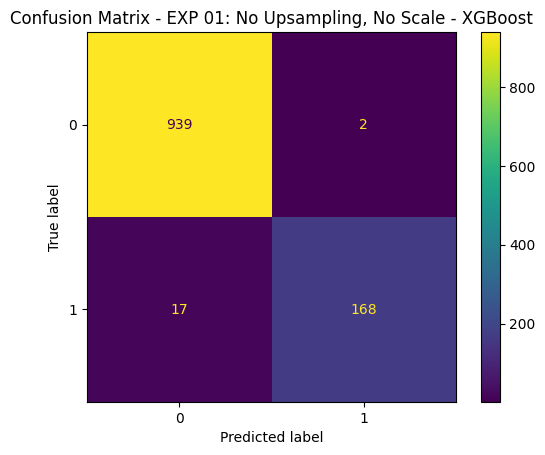

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
# EXP 01: Không Upsampling, Không Scale — XGBoost:
X = dataset_hash_dummy_drop_corr.drop(["Churn"], axis=1)
y = dataset_hash_dummy_drop_corr["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# XGBoost model
model_xgb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    eval_metric="logloss"
)

# Train model
model_xgb.fit(X_train, y_train)

# Predict
y_pred = model_xgb.predict(X_test)

# Lấy xác suất dự đoán lớp 1 để tính AUC-ROC
y_proba = model_xgb.predict_proba(X_test)[:, 1]

# In báo cáo kết quả
print(classification_report(y_test, y_pred))

# Tính AUC-ROC
auc_roc = roc_auc_score(y_test, y_proba)
print("AUC-ROC:", auc_roc)

# Vẽ confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_xgb.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 01: No Upsampling, No Scale - XGBoost")
plt.show()

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       941
           1       0.83      0.49      0.62       185

    accuracy                           0.90      1126
   macro avg       0.87      0.74      0.78      1126
weighted avg       0.89      0.90      0.89      1126

AUC-ROC: 0.8769738920642216


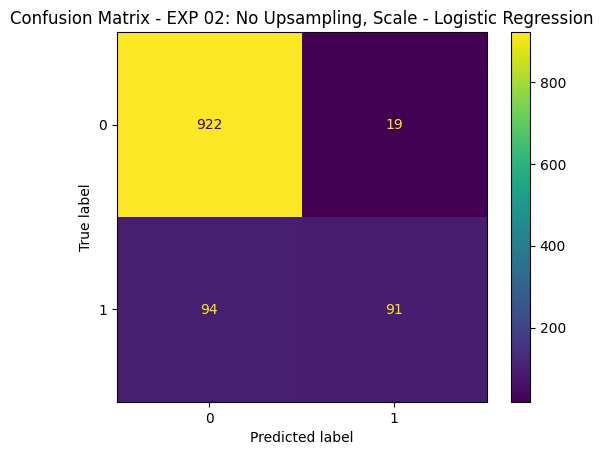

In [8]:
# EXP 02: Ko Upsampling, Scale. Model : Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
# Tách X và y
X = dataset_hash_dummy_drop_corr.drop(["Churn"], axis=1)
y = dataset_hash_dummy_drop_corr["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale dữ liệu
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
model_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
model_lr.fit(X_train_scaled, y_train)

# Predict
y_pred = model_lr.predict(X_test_scaled)

# Lấy xác suất lớp 1 để tính AUC-ROC
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# In báo cáo kết quả
print(classification_report(y_test, y_pred))

# Tính AUC-ROC
auc_roc = roc_auc_score(y_test, y_proba)
print("AUC-ROC:", auc_roc)

# Vẽ confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_lr.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 02: No Upsampling, Scale - Logistic Regression")
plt.show()

Trước SMOTE:
Churn
0    3741
1     763
Name: count, dtype: int64

Sau SMOTE:
Churn
0    3741
1    3741
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       941
           1       0.69      0.75      0.72       185

    accuracy                           0.90      1126
   macro avg       0.82      0.84      0.83      1126
weighted avg       0.91      0.90      0.91      1126

AUC-ROC: 0.9226584714363673


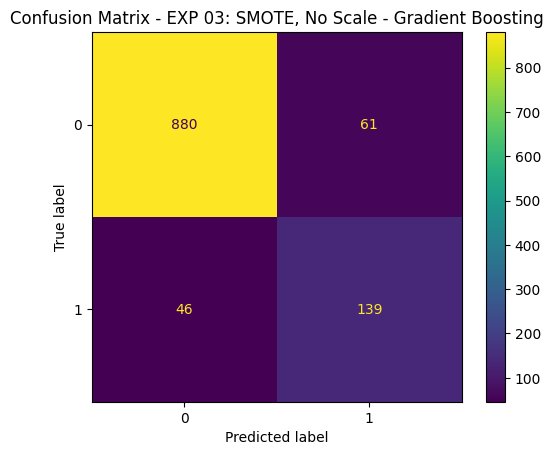

In [9]:
# Exp 03: Up Sampling bằng SMOTE, ko scale, model: GRADIENTBOOSTING
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Tách X và y
X = dataset_hash_dummy_drop_corr.drop(["Churn"], axis=1)
y = dataset_hash_dummy_drop_corr["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Upsampling bằng SMOTE
sm = SMOTE(
    k_neighbors=5,
    random_state=42
)

X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)

# Kiểm tra số lượng mẫu trước và sau SMOTE
print("Trước SMOTE:")
print(y_train.value_counts())

print("\nSau SMOTE:")
print(y_train_resample.value_counts())

# Gradient Boosting model
model_gb = GradientBoostingClassifier(
    random_state=42
)

# Train model bằng dữ liệu đã SMOTE
model_gb.fit(X_train_resample, y_train_resample)

# Predict trên tập test gốc
y_pred = model_gb.predict(X_test)

# Lấy xác suất lớp 1 để tính AUC-ROC
y_proba = model_gb.predict_proba(X_test)[:, 1]

# In báo cáo kết quả
print(classification_report(y_test, y_pred))

# Tính AUC-ROC
auc_roc = roc_auc_score(y_test, y_proba)
print("AUC-ROC:", auc_roc)

# Vẽ confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_gb.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 03: SMOTE, No Scale - Gradient Boosting")
plt.show()